(34660, 21)
['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']
<class 'pandas.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  str    
 1   name                  27900 non-null  str    
 2   asins                 34658 non-null  str    
 3   brand                 34660 non-null  str    
 4   categories            34660 non-null  str    
 5   keys                  34660 non-null  str    
 6   manufacturer          34660 non-null  str    
 7   reviews.date          34621 non-null  str    
 8   reviews.dateAdded     24039 

C:\Users\Admin\AppData\Local\Temp\ipykernel_24476\2604875787.py:3: DtypeWarning: Columns (1: name, 10: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/Consumer_Reviews_of_Amazon_Products.csv")


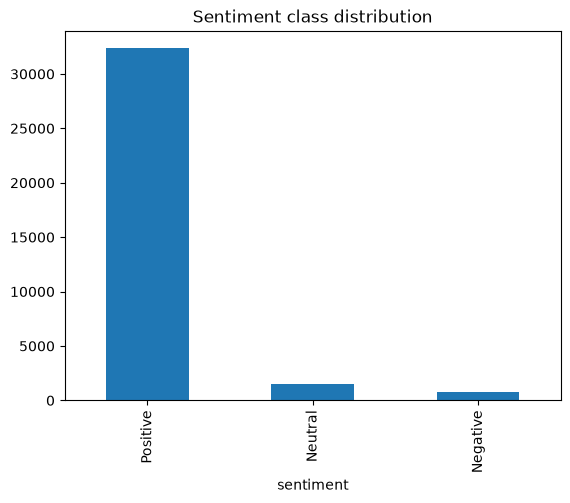


--- Positive example ---
great for reading outside in the sun, or in dark rooms. very easy on the eyes.

--- Neutral example ---
my kids get a lot of use out of their tablets. however, I wish the battery life was better.

--- Negative example ---
did not power up...at all. I am so happy that my grand-niece wasn't here and doesn't know about this yet, she would have been crying.
(27700,) (6926,)


In [9]:
import pandas as pd

df = pd.read_csv("../data/Consumer_Reviews_of_Amazon_Products.csv")

print(df.shape)
print(df.columns.tolist())
df.head()
df.info()
df[['name', 'reviews.rating', 'reviews.text']].head(10)

def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df['sentiment'] = df['reviews.rating'].apply(rating_to_sentiment)
df['sentiment'].value_counts()

import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar', title='Sentiment class distribution')
plt.show()


df[['reviews.text', 'reviews.rating']].isnull().sum()

# Drop rows with no review text or no rating — can't use them
df = df.dropna(subset=['reviews.text', 'reviews.rating'])

df.duplicated(subset=['reviews.text']).sum()
df = df.drop_duplicates(subset=['reviews.text'])

df['review_length'] = df['reviews.text'].str.split().apply(len)
df['review_length'].describe()

# Read a few examples from each class
for label in ['Positive', 'Neutral', 'Negative']:
    print(f"\n--- {label} example ---")
    print(df[df['sentiment'] == label]['reviews.text'].sample(1).values[0])



from sklearn.model_selection import train_test_split

X = df['reviews.text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)